# Quantum Kernel SVM vs Classical RBF-SVM: A Comparative Study

## Overview

This notebook demonstrates a comprehensive comparison between a classical **Support Vector Classifier (SVC)** using an **RBF kernel** and **Quantum Kernel-based SVCs** (both static and trainable) using **Qiskit’s Quantum Kernel Training (QKT)** toolkit.

**Date:** 3 Dec 2025

---

### Dataset Focus
We utilize the **Breast Cancer Wisconsin (Diagnostic) Dataset**. This dataset contains 30 real-valued features (such as mean radius, texture, and perimeter) computed from digitized images of fine needle aspirates (FNA) of breast masses.

### Why this dataset?
* **High-Dimensional Complexity:** The 30-feature space is ideal for testing if quantum feature maps can identify complex non-linear patterns that may be inaccessible to standard classical kernels.
* **Binary Classification Benchmark:** As a "Gold Standard" for Malignant vs. Benign classification, it provides a reliable baseline to measure the performance and potential accuracy lift of quantum-enhanced methods.
* **Optimization Potential:** The inherent physical correlations between features make it an excellent candidate for **Trainable Quantum Kernels**, where circuit parameters are optimized to maximize class separation in the quantum feature space.

---

In [1]:
# ============================================================================
# SETUP AND IMPORTS
# ============================================================================

# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import kagglehub

# Scikit-learn - Classical ML
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.decomposition import PCA

# Qiskit - Quantum Computing
from qiskit.primitives import StatevectorSampler
from qiskit.circuit.library import ZZFeatureMap

# Qiskit Machine Learning - Quantum Kernels
from qiskit_machine_learning.kernels import FidelityQuantumKernel, TrainableFidelityQuantumKernel
from qiskit_algorithms.state_fidelities import ComputeUncompute
from qiskit_machine_learning.algorithms import QSVC
from qiskit_machine_learning.kernels.algorithms import QuantumKernelTrainer
from qiskit.circuit import ParameterVector, QuantumCircuit
from qiskit_machine_learning.optimizers import SPSA

# Configuration
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
sns.set_style("whitegrid")

print("✓ Libraries imported successfully!")

✓ Libraries imported successfully!


In [2]:
# ============================================================================
# DATA ACQUISITION
# ============================================================================

# Download latest version of the UCI Breast Cancer dataset
path = kagglehub.dataset_download("uciml/breast-cancer-wisconsin-data")
print(f"Dataset downloaded to: {path}")

# Load dataset into a pandas DataFrame
# Note: The Kaggle download typically contains a 'data.csv' file
df = pd.read_csv(f"{path}/data.csv")

100%|██████████| 48.6k/48.6k [00:00<00:00, 214kB/s]

Extracting files...
Dataset downloaded to: C:\Users\uthupku\.cache\kagglehub\datasets\uciml\breast-cancer-wisconsin-data\versions\2


In [3]:
# ============================================================================
# EXPLORATORY DATA ANALYSIS (EDA)
# ============================================================================

# Basic info and checking for missing values
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [4]:
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [5]:
# ============================================================================
# DATA CLEANING & NULL CHECK
# ============================================================================

# Check for missing values
null_counts = df.isnull().sum()
if null_counts.any():
    print("Null values detected:\n", null_counts[null_counts > 0])
else:
    print("No null values found. Proceeding...")

# Drop artifacts: 'id' is useless for ML, 'Unnamed: 32'
cols_to_drop = ['id', 'Unnamed: 32']
df.drop(columns=[c for c in cols_to_drop if c in df.columns], inplace=True)

Null values detected:
 Unnamed: 32    569
dtype: int64


In [6]:
# Map target labels: M (Malignant) -> 1, B (Benign) -> 0
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

# Quick statistical summary of the features
print(df.describe().T)

                         count        mean         std         min  \
diagnosis                569.0    0.372583    0.483918    0.000000   
radius_mean              569.0   14.127292    3.524049    6.981000   
texture_mean             569.0   19.289649    4.301036    9.710000   
perimeter_mean           569.0   91.969033   24.298981   43.790000   
area_mean                569.0  654.889104  351.914129  143.500000   
smoothness_mean          569.0    0.096360    0.014064    0.052630   
compactness_mean         569.0    0.104341    0.052813    0.019380   
concavity_mean           569.0    0.088799    0.079720    0.000000   
concave points_mean      569.0    0.048919    0.038803    0.000000   
symmetry_mean            569.0    0.181162    0.027414    0.106000   
fractal_dimension_mean   569.0    0.062798    0.007060    0.049960   
radius_se                569.0    0.405172    0.277313    0.111500   
texture_se               569.0    1.216853    0.551648    0.360200   
perimeter_se        

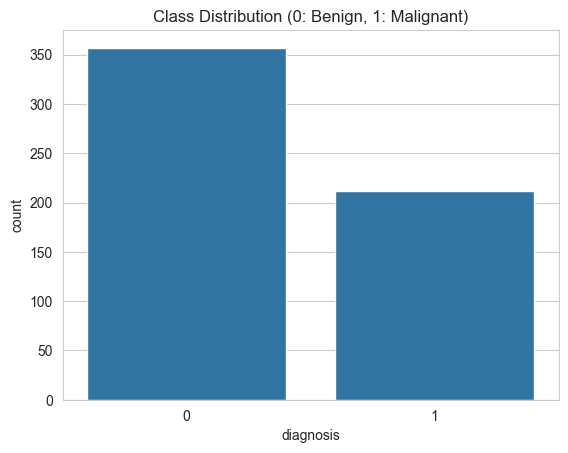

In [7]:
# Visualizing the class balance
sns.countplot(x='diagnosis', data=df)
plt.title("Class Distribution (0: Benign, 1: Malignant)")
plt.show()

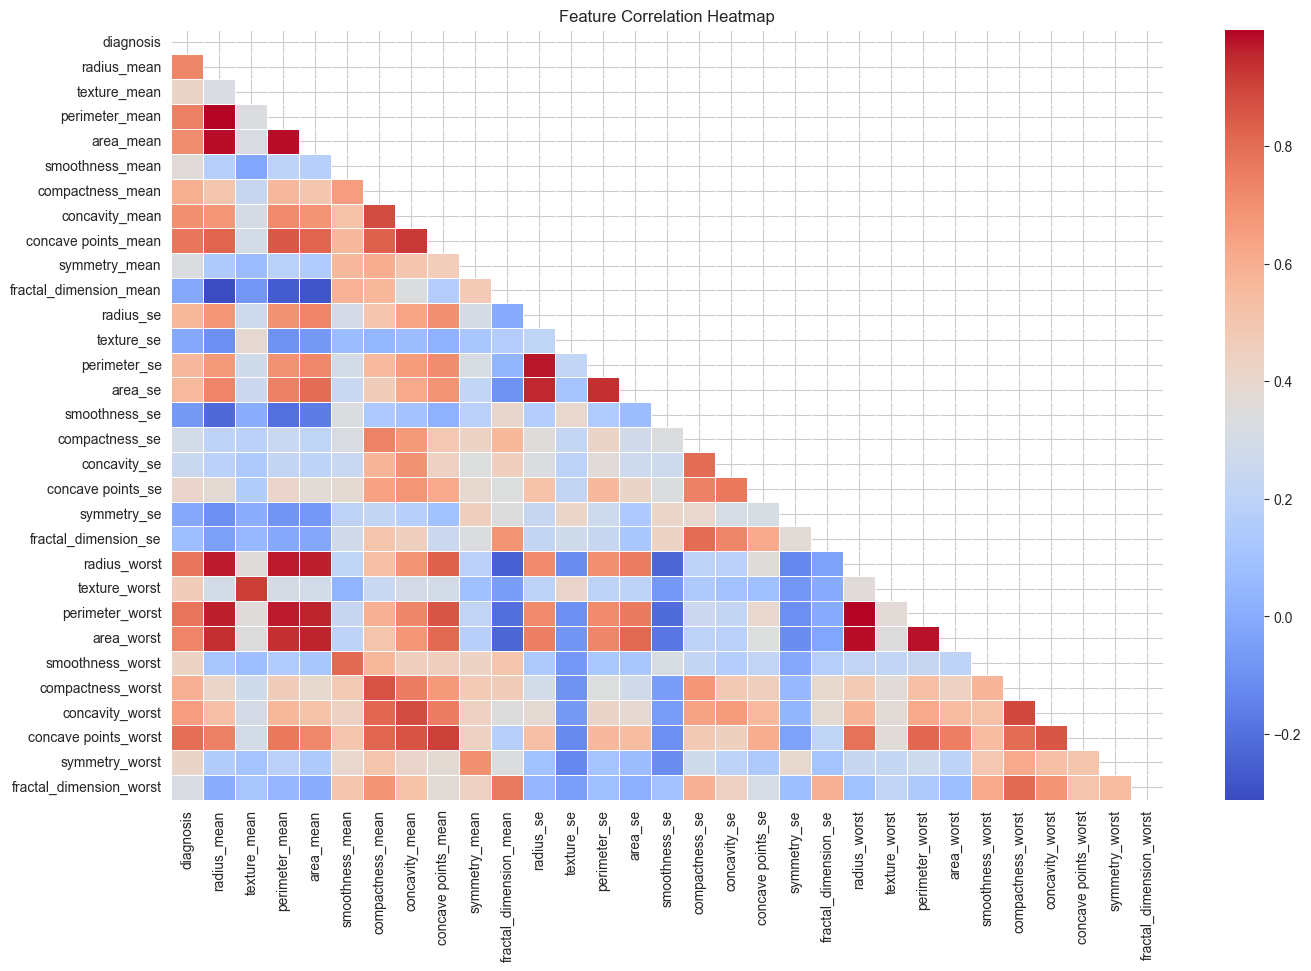

In [8]:
plt.figure(figsize=(16, 10))

# Calculate Pearson correlation
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()

### CLASSICAL SVC PIPELINE

In [9]:
# Define Features and Target
X = df.drop('diagnosis', axis=1)
y = df['diagnosis']

# Train-Test Split (80/20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [10]:
# Feature Scaling
# Crucial step: PCA and SVM both require zero mean and unit variance
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [11]:
# Apply PCA
# Reducing to 5 components to match future Quantum Kernel qubit constraints
n_components = 5
pca = PCA(n_components=n_components)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# Log variance retention for documentation
explained_var = np.sum(pca.explained_variance_ratio_) * 100
print(f"PCA complete. Total variance retained ({n_components} components): {explained_var:.2f}%")

PCA complete. Total variance retained (5 components): 84.52%


In [12]:

# Train Classical RBF SVC (The 'Apples-to-Apples' Baseline)
print("Training Classical SVC (RBF) on PCA features...")
start_time = time.time()
svc_pca = SVC(kernel='rbf', C=1.0, gamma='scale')
svc_pca.fit(X_train_pca, y_train)
classical_time = time.time() - start_time

Training Classical SVC (RBF) on PCA features...


In [13]:
# Evaluate Metrics
y_pred = svc_pca.predict(X_test_pca)
accuracy = accuracy_score(y_test, y_pred)

print(f"\n--- Classical SVC Results (5 PCA Features) ---")
print(f"Accuracy: {accuracy:.4f}")
print(f"Execution Time: {classical_time:.4f} seconds")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


--- Classical SVC Results (5 PCA Features) ---
Accuracy: 0.9649
Execution Time: 0.0050 seconds

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.97      0.97        71
           1       0.95      0.95      0.95        43

    accuracy                           0.96       114
   macro avg       0.96      0.96      0.96       114
weighted avg       0.96      0.96      0.96       114



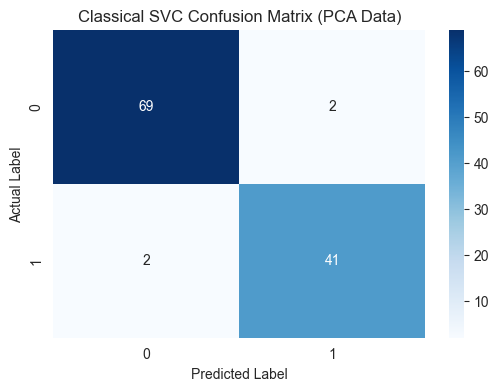

In [14]:
# Visualization: Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('Classical SVC Confusion Matrix (PCA Data)')
plt.show()

In [15]:
import joblib
import os

# Save the Scaler (to scale new data)
joblib.dump(scaler, 'models/scaler.joblib')

# Save the PCA object (to reduce new data to 5 features)
joblib.dump(pca, 'models/pca_processor.joblib')

# Save the trained SVC model
joblib.dump(svc_pca, 'models/classical_svc_baseline.joblib')

print("Pipeline saved successfully to the /models folder.")

Pipeline saved successfully to the /models folder.


### QUANTUM SVC PIPELINE

In [16]:
# Initialize Feature Map (5 Qubits for 5 PCA components)
# reps=2 is standard for capturing non-linear feature interactions
feature_map = ZZFeatureMap(feature_dimension=5, reps=2, entanglement='linear')

C:\Users\uthupku\AppData\Local\Temp\ipykernel_144\1703892101.py:3: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._zz_feature_map.ZZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the zz_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  feature_map = ZZFeatureMap(feature_dimension=5, reps=2, entanglement='linear')


In [17]:
# Setup Fidelity & Sampler (Simulation Backbone)
sampler = StatevectorSampler()
fidelity = ComputeUncompute(sampler=sampler)

# Define the Static Quantum Kernel
static_kernel = FidelityQuantumKernel(fidelity=fidelity, feature_map=feature_map)

In [18]:
# Train the Quantum SVC (Static)
print("Training Static Quantum SVC (QSVC)...")
start_time = time.time()
qsvc_static = QSVC(quantum_kernel=static_kernel)
qsvc_static.fit(X_train_pca, y_train)
static_q_time = time.time() - start_time

Training Static Quantum SVC (QSVC)...


In [19]:
# Predict on Test Data
print("Predicting with Static QSVC...")
start_pred_time = time.time()
y_pred_static = qsvc_static.predict(X_test_pca)
static_pred_duration = time.time() - start_pred_time

Predicting with Static QSVC...


In [20]:
# Calculate Performance Metrics
static_accuracy = accuracy_score(y_test, y_pred_static)

print(f"\n--- Static Quantum SVC Results ---")
print(f"Accuracy:        {static_accuracy:.4f}")
print(f"Training Time:   {static_q_time:.4f}s")
print(f"Prediction Time: {static_pred_duration:.4f}s")

print("\nQuantum Classification Report:")
print(classification_report(y_test, y_pred_static))


--- Static Quantum SVC Results ---
Accuracy:        0.6140
Training Time:   732.5898s
Prediction Time: 383.2372s

Quantum Classification Report:
              precision    recall  f1-score   support

           0       0.64      0.89      0.74        71
           1       0.47      0.16      0.24        43

    accuracy                           0.61       114
   macro avg       0.55      0.53      0.49       114
weighted avg       0.57      0.61      0.55       114



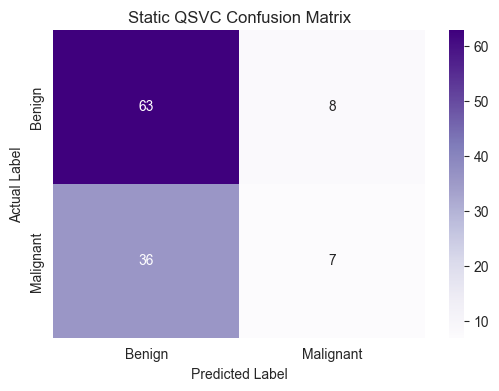

In [21]:
# Visualization: Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_static), 
            annot=True, 
            fmt='d', 
            cmap='Purples',
            xticklabels=['Benign', 'Malignant'],
            yticklabels=['Benign', 'Malignant'])
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('Static QSVC Confusion Matrix')
plt.show()

In [22]:
# Save the QSVC Model
joblib.dump(qsvc_static, 'models/qsvc_static_model.joblib')

print("Static Quantum Pipeline saved successfully.")

Static Quantum Pipeline saved successfully.


### QUANTUM KERNEL ALIGNMENT (QKA)

In [23]:

# Create a Trainable "Ansatz" Layer
user_params = ParameterVector("θ", 1)
ansatz = QuantumCircuit(5)
ansatz.ry(user_params[0], range(5)) # Apply rotation to all 5 qubits

In [24]:
X_train_small, _, y_train_small, _ = train_test_split(
    X_train_pca, 
    y_train, 
    train_size=100,
    stratify=y_train,  # Preserve class distribution
    random_state=42
)

In [25]:
# Combine Ansatz with Feature Map
trainable_fm = ansatz.compose(feature_map)

# Setup Trainable Kernel
trainable_kernel = TrainableFidelityQuantumKernel(
    fidelity=fidelity, 
    feature_map=trainable_fm, 
    training_parameters=user_params
)

# Initialize Trainer (Using SPSA Optimizer for noisy/quantum landscapes)
qkt = QuantumKernelTrainer(
    quantum_kernel=trainable_kernel, 
    optimizer=SPSA(maxiter=10), # Start small (10-20 iterations) for local testing
)

In [26]:
# Train the Kernel Parameters (Quantum Kernel Alignment)
print("Initiating Quantum Kernel Alignment (Optimizing θ)...")
start_alignment_time = time.time()

qkt_results = qkt.fit(X_train_small, y_train_small)
optimized_kernel = qkt_results.quantum_kernel

alignment_duration = time.time() - start_alignment_time

Initiating Quantum Kernel Alignment (Optimizing θ)...


In [27]:
# Train the QSVC using the Optimized Kernel
print("Training QSVC with optimized parameters...")
start_train_time = time.time()

qsvc_trainable = QSVC(quantum_kernel=optimized_kernel)
qsvc_trainable.fit(X_train_pca, y_train)

trainable_train_duration = time.time() - start_train_time

Training QSVC with optimized parameters...


In [28]:
# Predict on Test Data
print("Predicting with Trainable QSVC...")
start_pred_time = time.time()

y_pred_trainable = qsvc_trainable.predict(X_test_pca)

trainable_pred_duration = time.time() - start_pred_time

Predicting with Trainable QSVC...


In [29]:
# Calculate Performance Metrics
trainable_accuracy = accuracy_score(y_test, y_pred_trainable)

print(f"\n--- Trainable Quantum SVC Results ---")
print(f"Accuracy:           {trainable_accuracy:.4f}")
print(f"Alignment Time:     {alignment_duration:.4f}s")
print(f"SVC Training Time:  {trainable_train_duration:.4f}s")
print(f"Prediction Time:    {trainable_pred_duration:.4f}s")
print(f"Optimal θ:          {qkt_results.optimal_parameters}")

print("\nTrainable Quantum Classification Report:")
print(classification_report(y_test, y_pred_trainable))


--- Trainable Quantum SVC Results ---
Accuracy:           0.5789
Alignment Time:     3049.3103s
SVC Training Time:  920.0671s
Prediction Time:    415.3647s
Optimal θ:          {ParameterVectorElement(θ[0]): np.float64(2.673778956974138)}

Trainable Quantum Classification Report:
              precision    recall  f1-score   support

           0       0.62      0.82      0.71        71
           1       0.38      0.19      0.25        43

    accuracy                           0.58       114
   macro avg       0.50      0.50      0.48       114
weighted avg       0.53      0.58      0.53       114



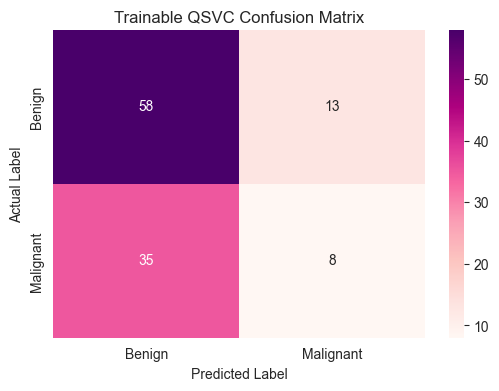

In [30]:
# Visualization: Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_trainable), 
            annot=True, 
            fmt='d', 
            cmap='RdPu', # Different color to distinguish from Static
            xticklabels=['Benign', 'Malignant'],
            yticklabels=['Benign', 'Malignant'])
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('Trainable QSVC Confusion Matrix')
plt.show()

In [31]:
# Save the QSVC Model
joblib.dump(qsvc_trainable, 'models/qka_opt_model.joblib')

print("Static Quantum Pipeline saved successfully.")

Static Quantum Pipeline saved successfully.


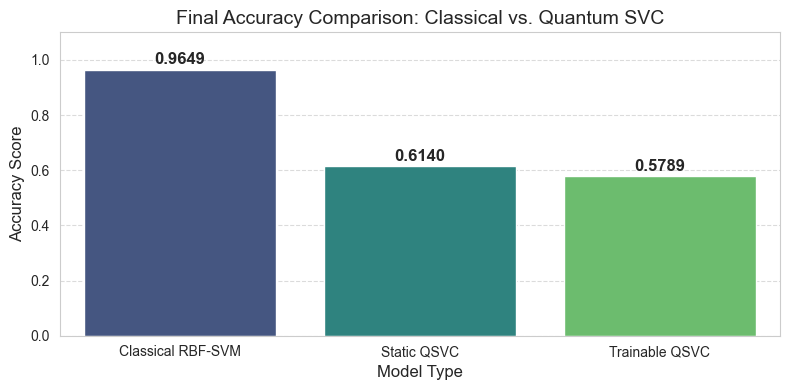

In [36]:
# Create the summary table using your pre-calculated variables
comparison_data = {
    "Model": ["Classical RBF-SVM", "Static QSVC", "Trainable QSVC"],
    "Accuracy Score": [accuracy, static_accuracy, trainable_accuracy]
}

df_comparison = pd.DataFrame(comparison_data)

# Create the visualization
plt.figure(figsize=(8, 4))

# Fix: Added hue="Model" and legend=False to address the FutureWarning
sns.barplot(
    x="Model", 
    y="Accuracy Score", 
    data=df_comparison, 
    hue="Model", 
    palette="viridis", 
    legend=False
)

# Fix: Changed ylim to start from 0 so the 0.61 and 0.57 bars are visible
plt.ylim(0, 1.1) 

# Add text labels on top of bars
for i, val in enumerate(df_comparison['Accuracy Score']):
    plt.text(i, val + 0.02, f'{val:.4f}', ha='center', fontweight='bold', fontsize=12)

plt.title("Final Accuracy Comparison: Classical vs. Quantum SVC", fontsize=14)
plt.ylabel("Accuracy Score", fontsize=12)
plt.xlabel("Model Type", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# Model Comparison Report: Classical vs. Quantum SVC

## 1. Final Results Summary
The table below summarizes the test accuracy for each model on the Breast Cancer dataset.

| Model | Accuracy Score |
| :--- | :--- |
| **Classical RBF-SVM** | **0.9649** |
| **Static QSVC** | **0.6140** |
| **Trainable QSVC** | **0.5789** |

---

## 2. Conclusions & Analysis

The performance gap between the Classical and Quantum models in this experiment can be attributed to several key factors:

* **Classical RBF Efficiency:** The Radial Basis Function (RBF) kernel is a "gold standard" for non-linear classification on medium-sized datasets. It is highly optimized to find decision boundaries in feature spaces that naturally suit biological datasets like Breast Cancer.
* **Feature Map Suitability:** The **Static QSVC** used a `ZZFeatureMap`. Quantum feature maps are not "one size fits all." If the mathematical structure of the `ZZFeatureMap` does not align with the underlying distribution of the cancer diagnostic data, the model will struggle to separate the classes effectively.
* **Optimization Sensitivity:** The **Trainable QSVC** showed lower performance than the static version. This is likely due to the **SPSA optimizer** settings:
    * **Convergence:** Quantum Kernel Training (QKT) often requires a high number of iterations and fine-tuned learning rates to find an optimal kernel.
    * **Stochastic Nature:** SPSA is a noise-resilient but stochastic optimizer; without enough iterations, it may drift away from a good solution rather than toward one.
* **Simulation Constraints:** The quantum models were run on a simulator. Limitations in circuit depth and the number of "shots" (sampling) can introduce variance that prevents the quantum kernel from reaching the precision of a classical mathematical function.